In [1]:
# Import các thư viện cần thiết
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Chuẩn bị dữ liệu
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

100.0%
100.0%
100.0%
100.0%


=== CÂU 1: Huấn luyện với 10 epochs ===
Epoch 1, Loss: 0.2679, Accuracy: 91.69%
Epoch 2, Loss: 0.0866, Accuracy: 97.33%
Epoch 3, Loss: 0.0657, Accuracy: 98.00%
Epoch 4, Loss: 0.0544, Accuracy: 98.31%
Epoch 5, Loss: 0.0483, Accuracy: 98.53%
Epoch 6, Loss: 0.0429, Accuracy: 98.71%
Epoch 7, Loss: 0.0384, Accuracy: 98.80%
Epoch 8, Loss: 0.0352, Accuracy: 98.94%
Epoch 9, Loss: 0.0327, Accuracy: 98.97%
Epoch 10, Loss: 0.0301, Accuracy: 99.08%

Độ chính xác trên tập test (10 epochs): 98.87%


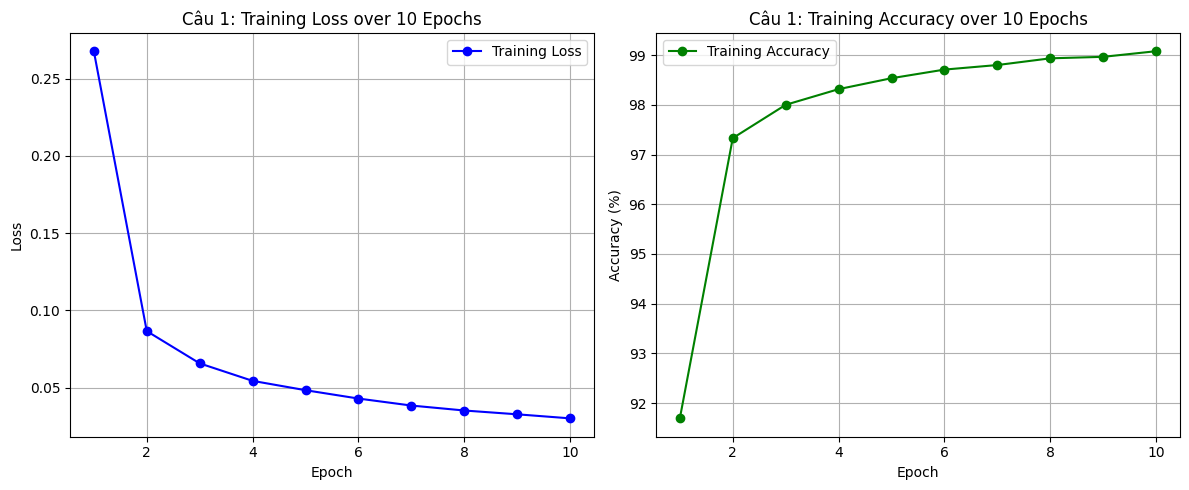

In [2]:
"""
### CÂU 1: Tăng số epoch lên 10
- Thay đổi: for epoch in range(5) -> for epoch in range(10)
- Mục đích: Cho mô hình học lâu hơn, có thể đạt độ chính xác cao hơn
"""

class MNIST_CNN_Cau1(nn.Module):
    def __init__(self):
        super(MNIST_CNN_Cau1, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 5 * 5)
        x = self.fc1(x)
        return x

model_c1 = MNIST_CNN_Cau1()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_c1.parameters(), lr=0.01, momentum=0.9)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_c1.to(device)

loss_values_c1 = []
accuracy_values_c1 = []

print("=== CÂU 1: Huấn luyện với 10 epochs ===")
for epoch in range(10): 
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_c1(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    loss_values_c1.append(epoch_loss)
    accuracy_values_c1.append(epoch_accuracy)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

# Đánh giá trên tập test
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_c1(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
test_accuracy_c1 = 100 * correct / total
print(f"\nĐộ chính xác trên tập test (10 epochs): {test_accuracy_c1:.2f}%")

# Vẽ biểu đồ
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 11), loss_values_c1, marker='o', color='b', label='Training Loss')
plt.title('Câu 1: Training Loss over 10 Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, 11), accuracy_values_c1, marker='o', color='g', label='Training Accuracy')
plt.title('Câu 1: Training Accuracy over 10 Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [3]:
"""
### CÂU 2: Thêm tầng tích chập thứ ba (conv3)
- Thêm self.conv3 với 64 kênh đầu ra
- Điều chỉnh kích thước đầu vào của fc1
"""

class MNIST_CNN_Cau2(nn.Module):
    def __init__(self):
        super(MNIST_CNN_Cau2, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        # Thêm tầng tích chập thứ 3
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=0)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # Điều chỉnh kích thước: 64 kênh * 1 * 1 (sau khi qua conv3 và pool)
        self.fc1 = nn.Linear(64 * 1 * 1, 10)

    def forward(self, x):
        # Tính toán kích thước:
        # Input: 28x28
        x = self.pool(torch.relu(self.conv1(x)))  # 26x26 -> 13x13 sau pool
        x = self.pool(torch.relu(self.conv2(x)))  # 11x11 -> 5x5 sau pool
        x = self.pool(torch.relu(self.conv3(x)))  # 3x3 -> 1x1 sau pool
        x = x.view(-1, 64 * 1 * 1)  # Duỗi thành vector 64 chiều
        x = self.fc1(x)
        return x

# Khởi tạo và huấn luyện
model_c2 = MNIST_CNN_Cau2()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_c2.parameters(), lr=0.01, momentum=0.9)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_c2.to(device)

loss_values_c2 = []
accuracy_values_c2 = []

print("\n=== CÂU 2: Huấn luyện với tầng conv3 ===")
for epoch in range(5):  # Giữ nguyên 5 epochs để so sánh
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_c2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    loss_values_c2.append(epoch_loss)
    accuracy_values_c2.append(epoch_accuracy)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

# Đánh giá trên tập test
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_c2(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
test_accuracy_c2 = 100 * correct / total
print(f"\nĐộ chính xác trên tập test (có conv3): {test_accuracy_c2:.2f}%")

# So sánh với mô hình gốc
print(f"\nSo sánh độ chính xác:")
print(f"- Mô hình gốc (2 tầng conv): ~98%")
print(f"- Mô hình có conv3: {test_accuracy_c2:.2f}%")


=== CÂU 2: Huấn luyện với tầng conv3 ===
Epoch 1, Loss: 0.5054, Accuracy: 83.64%
Epoch 2, Loss: 0.1242, Accuracy: 96.18%
Epoch 3, Loss: 0.0864, Accuracy: 97.37%
Epoch 4, Loss: 0.0715, Accuracy: 97.77%
Epoch 5, Loss: 0.0604, Accuracy: 98.15%

Độ chính xác trên tập test (có conv3): 98.24%

So sánh độ chính xác:
- Mô hình gốc (2 tầng conv): ~98%
- Mô hình có conv3: 98.24%



--- Huấn luyện với learning rate = 0.001 ---
Epoch 1, Loss: 0.8128, Accuracy: 79.54%
Epoch 2, Loss: 0.2530, Accuracy: 92.58%
Epoch 3, Loss: 0.1807, Accuracy: 94.74%
Epoch 4, Loss: 0.1464, Accuracy: 95.75%
Epoch 5, Loss: 0.1252, Accuracy: 96.31%
Độ chính xác trên tập test (lr=0.001): 96.83%

--- Huấn luyện với learning rate = 0.01 ---
Epoch 1, Loss: 0.2977, Accuracy: 90.83%
Epoch 2, Loss: 0.0880, Accuracy: 97.31%
Epoch 3, Loss: 0.0685, Accuracy: 97.87%
Epoch 4, Loss: 0.0574, Accuracy: 98.24%
Epoch 5, Loss: 0.0504, Accuracy: 98.48%
Độ chính xác trên tập test (lr=0.01): 98.57%

--- Huấn luyện với learning rate = 0.1 ---
Epoch 1, Loss: 0.1690, Accuracy: 94.76%
Epoch 2, Loss: 0.0682, Accuracy: 97.88%
Epoch 3, Loss: 0.0587, Accuracy: 98.19%
Epoch 4, Loss: 0.0505, Accuracy: 98.52%
Epoch 5, Loss: 0.0448, Accuracy: 98.66%
Độ chính xác trên tập test (lr=0.1): 98.43%


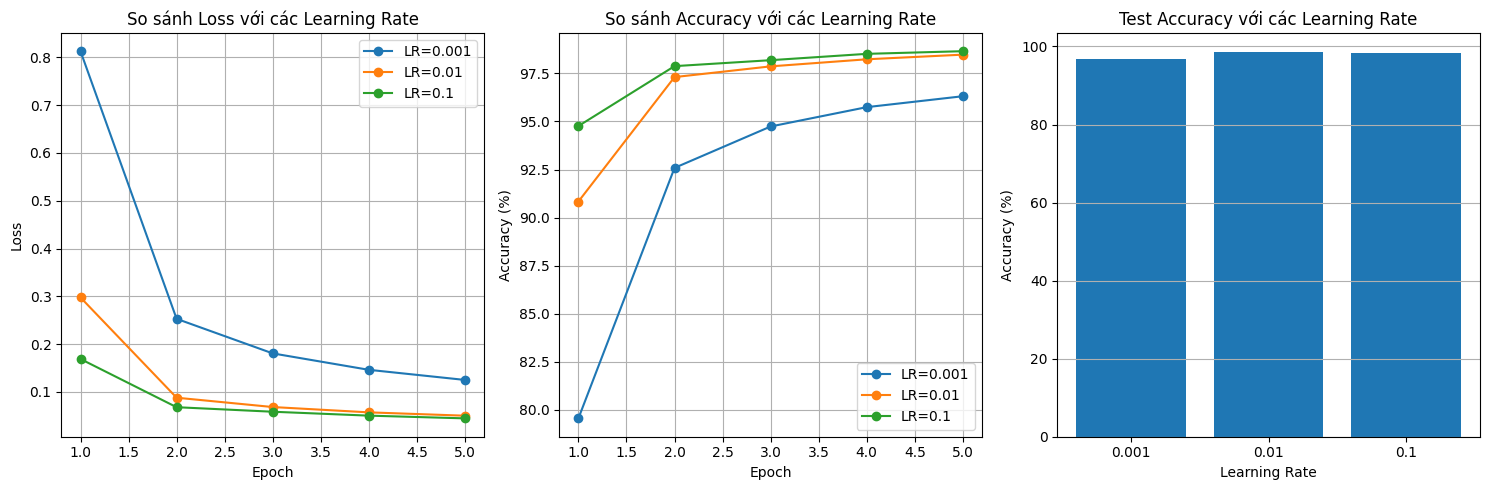


=== Tổng kết Câu 3 ===
Learning rate 0.001: Test accuracy = 96.83%
Learning rate 0.01: Test accuracy = 98.57%
Learning rate 0.1: Test accuracy = 98.43%


In [4]:
"""
### CÂU 3: Thay đổi learning rate
- Thử nghiệm với lr = 0.001 và lr = 0.1
- So sánh với lr = 0.01 ban đầu
"""

def train_with_lr(learning_rate, model_name):
    """Hàm huấn luyện với learning rate cụ thể"""
    
    class MNIST_CNN(nn.Module):
        def __init__(self):
            super(MNIST_CNN, self).__init__()
            self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
            self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
            self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
            self.fc1 = nn.Linear(32 * 5 * 5, 10)

        def forward(self, x):
            x = self.pool(torch.relu(self.conv1(x)))
            x = self.pool(torch.relu(self.conv2(x)))
            x = x.view(-1, 32 * 5 * 5)
            x = self.fc1(x)
            return x
    
    model = MNIST_CNN()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    loss_values = []
    accuracy_values = []
    
    print(f"\n--- Huấn luyện với learning rate = {learning_rate} ---")
    for epoch in range(5):
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * correct / total
        loss_values.append(epoch_loss)
        accuracy_values.append(epoch_accuracy)
        print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")
    
    # Đánh giá trên tập test
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    test_accuracy = 100 * correct / total
    print(f"Độ chính xác trên tập test (lr={learning_rate}): {test_accuracy:.2f}%")
    
    return loss_values, accuracy_values, test_accuracy

# Thử nghiệm với 3 learning rate khác nhau
learning_rates = [0.001, 0.01, 0.1]
results = {}

for lr in learning_rates:
    loss_vals, acc_vals, test_acc = train_with_lr(lr, f"LR_{lr}")
    results[lr] = {
        'loss': loss_vals,
        'accuracy': acc_vals,
        'test_accuracy': test_acc
    }

# Vẽ biểu đồ so sánh
plt.figure(figsize=(15, 5))

# Biểu đồ loss
plt.subplot(1, 3, 1)
for lr in learning_rates:
    plt.plot(range(1, 6), results[lr]['loss'], marker='o', label=f'LR={lr}')
plt.title('So sánh Loss với các Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Biểu đồ accuracy
plt.subplot(1, 3, 2)
for lr in learning_rates:
    plt.plot(range(1, 6), results[lr]['accuracy'], marker='o', label=f'LR={lr}')
plt.title('So sánh Accuracy với các Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

# Biểu đồ test accuracy
plt.subplot(1, 3, 3)
lrs = list(results.keys())
test_accs = [results[lr]['test_accuracy'] for lr in lrs]
plt.bar(range(len(lrs)), test_accs, tick_label=lrs)
plt.title('Test Accuracy với các Learning Rate')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy (%)')
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

print("\n=== Tổng kết Câu 3 ===")
for lr in learning_rates:
    print(f"Learning rate {lr}: Test accuracy = {results[lr]['test_accuracy']:.2f}%")

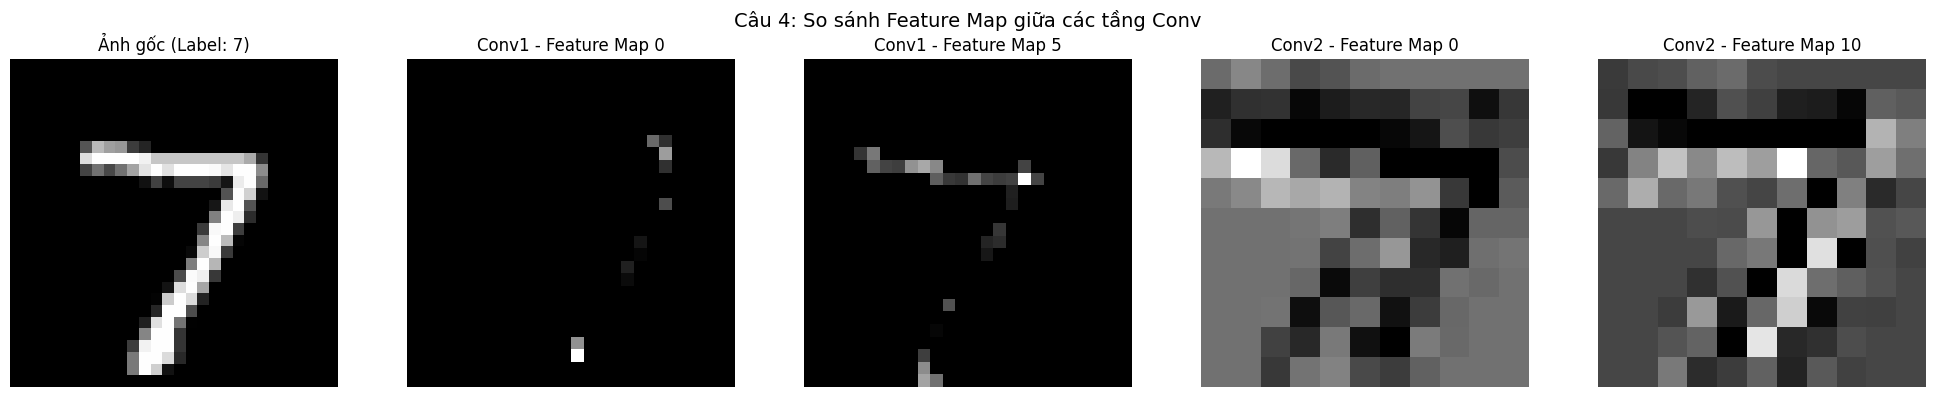

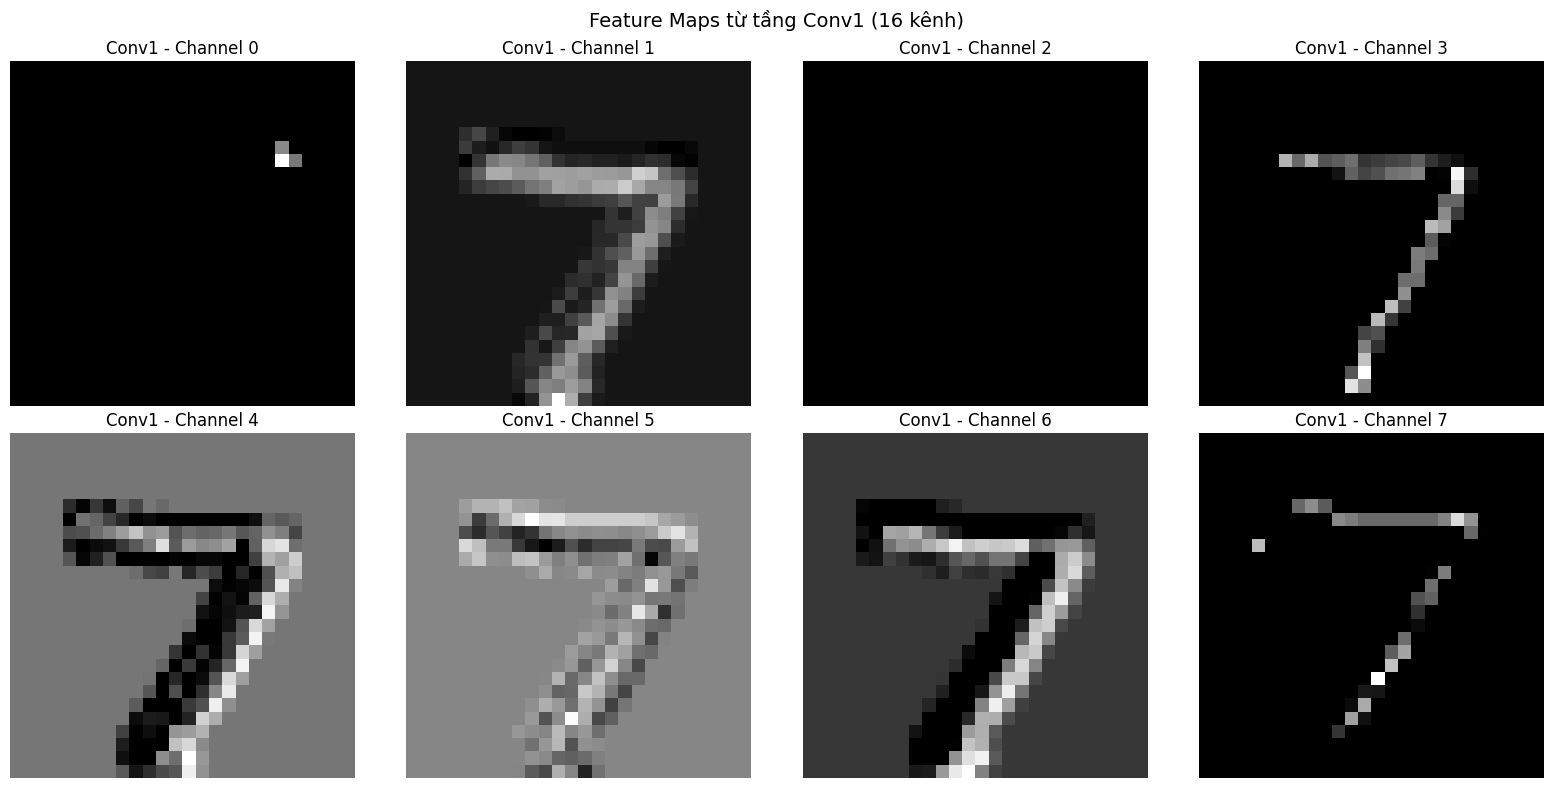

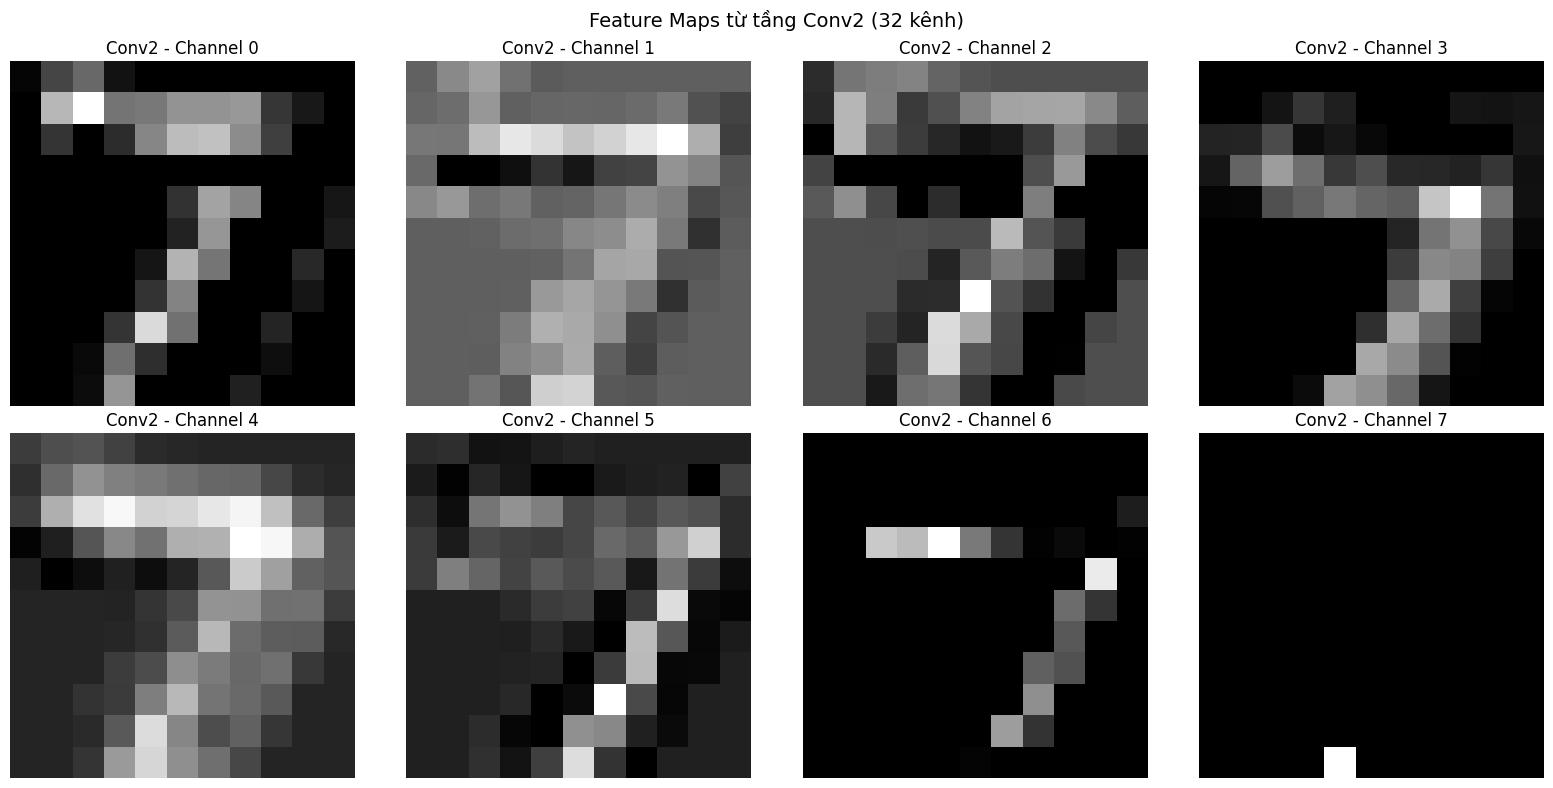

In [5]:
"""
### CÂU 4: Vẽ thêm feature map từ tầng conv2
- Mở rộng hàm visualize_feature_map để hiển thị cả feature map từ conv1 và conv2
- So sánh sự khác biệt giữa các tầng
"""

def visualize_feature_map_cau4():
    """Vẽ ảnh gốc và feature map từ conv1 và conv2"""
    
    # Sử dụng mô hình từ câu 2 (có conv3) hoặc tạo mô hình mới
    class MNIST_CNN_Visual(nn.Module):
        def __init__(self):
            super(MNIST_CNN_Visual, self).__init__()
            self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
            self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
            self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
            self.fc1 = nn.Linear(32 * 5 * 5, 10)

        def forward(self, x):
            x = self.pool(torch.relu(self.conv1(x)))
            x = self.pool(torch.relu(self.conv2(x)))
            x = x.view(-1, 32 * 5 * 5)
            x = self.fc1(x)
            return x
    
    model = MNIST_CNN_Visual()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    
    # Lấy ảnh từ tập test
    images, labels = next(iter(test_loader))
    img = images[0].unsqueeze(0).to(device)
    true_label = labels[0].item()
    
    # Tính feature map
    # Qua conv1 và ReLU
    conv1_output = torch.relu(model.conv1(img))  # Shape: 1x16x26x26
    # Qua pool và conv2
    x = model.pool(conv1_output)  # 1x16x13x13
    conv2_output = torch.relu(model.conv2(x))  # 1x32x11x11
    
    # Vẽ 5 subplot: ảnh gốc + 2 feature map từ conv1 + 2 feature map từ conv2
    plt.figure(figsize=(20, 4))
    
    # Ảnh gốc
    plt.subplot(1, 5, 1)
    plt.title(f"Ảnh gốc (Label: {true_label})")
    plt.imshow(img.cpu().squeeze(), cmap='gray')
    plt.axis('off')
    
    # Feature map từ conv1 (channel 0 và 5)
    plt.subplot(1, 5, 2)
    plt.title("Conv1 - Feature Map 0")
    plt.imshow(conv1_output[0, 0].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 5, 3)
    plt.title("Conv1 - Feature Map 5")
    plt.imshow(conv1_output[0, 5].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')
    
    # Feature map từ conv2 (channel 0 và 10)
    plt.subplot(1, 5, 4)
    plt.title("Conv2 - Feature Map 0")
    plt.imshow(conv2_output[0, 0].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 5, 5)
    plt.title("Conv2 - Feature Map 10")
    plt.imshow(conv2_output[0, 10].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')
    
    plt.suptitle("Câu 4: So sánh Feature Map giữa các tầng Conv", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return conv1_output, conv2_output

# Gọi hàm vẽ
conv1_out, conv2_out = visualize_feature_map_cau4()

# Phân tích thêm: Vẽ nhiều feature map hơn để thấy rõ sự khác biệt
def visualize_multiple_features():
    """Vẽ nhiều feature map từ conv1 và conv2 để so sánh"""
    
    class MNIST_CNN_Visual(nn.Module):
        def __init__(self):
            super(MNIST_CNN_Visual, self).__init__()
            self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
            self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
            self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
            self.fc1 = nn.Linear(32 * 5 * 5, 10)

        def forward(self, x):
            x = self.pool(torch.relu(self.conv1(x)))
            x = self.pool(torch.relu(self.conv2(x)))
            x = x.view(-1, 32 * 5 * 5)
            x = self.fc1(x)
            return x
    
    model = MNIST_CNN_Visual()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    
    images, labels = next(iter(test_loader))
    img = images[0].unsqueeze(0).to(device)
    
    # Tính feature map
    conv1_output = torch.relu(model.conv1(img))
    x = model.pool(conv1_output)
    conv2_output = torch.relu(model.conv2(x))
    
    # Vẽ 8 feature map từ conv1
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle("Feature Maps từ tầng Conv1 (16 kênh)", fontsize=14)
    
    for i in range(8):
        row = i // 4
        col = i % 4
        axes[row, col].imshow(conv1_output[0, i].cpu().detach().numpy(), cmap='gray')
        axes[row, col].set_title(f"Conv1 - Channel {i}")
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Vẽ 8 feature map từ conv2
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle("Feature Maps từ tầng Conv2 (32 kênh)", fontsize=14)
    
    for i in range(8):
        row = i // 4
        col = i % 4
        axes[row, col].imshow(conv2_output[0, i].cpu().detach().numpy(), cmap='gray')
        axes[row, col].set_title(f"Conv2 - Channel {i}")
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()

# Gọi hàm vẽ nhiều feature map
visualize_multiple_features()